In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [19]:
# =========================================================
# Question 1 : Charger le jeu de données dans un DataFrame
# =========================================================
import pandas as pd
df = pd.read_csv(r"C:\Users\EBUSER\Downloads\house_prices_100.csv")
print("Q1 - Aperçu du DataFrame :")
print(df.head())
print()

Q1 - Aperçu du DataFrame :
   area   price
0  4174  773729
1  4507  832471
2  1860  350497
3  2294  399985
4  2130  425493



In [8]:
# =========================================================
# Question 2 : Types de données + valeurs manquantes
# =========================================================
print("Q2 - Types de données :")
print(df.dtypes)
print()

Q2 - Types de données :
area     int64
price    int64
dtype: object



In [9]:
print("Q2 - Valeurs manquantes par colonne :")
print(df.isnull().sum())
print()

Q2 - Valeurs manquantes par colonne :
area     0
price    0
dtype: int64



In [10]:
for col in df.select_dtypes(include=[np.number]).columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())  # médiane = plus robuste aux valeurs extrêmes

print("Q2 - Valeurs manquantes après traitement :")
print(df.isnull().sum())
print()

Q2 - Valeurs manquantes après traitement :
area     0
price    0
dtype: int64



In [11]:
# =========================================================
# Question 3 : Division train / test
# =========================================================
X = df[["area"]]   # variable explicative (indépendante)
y = df["price"]    # variable cible (dépendante)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Q3 - Taille train : {X_train.shape[0]} lignes | Taille test : {X_test.shape[0]} lignes")
print()

Q3 - Taille train : 70 lignes | Taille test : 30 lignes



In [12]:
# =========================================================
# Question 4 : Création du modèle de régression (sklearn)
# =========================================================
model = LinearRegression()
print("Q4 - Modèle créé :", model)
print()

Q4 - Modèle créé : LinearRegression()



In [13]:
# =========================================================
# Question 5 : Entraînement + évaluation (MSE)
# ========================================================
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
mse_train = mean_squared_error(y_train, y_pred_train)
print(f"Q5 - MSE sur l'ensemble d'entraînement : {mse_train:,.2f}")
print()

Q5 - MSE sur l'ensemble d'entraînement : 798,702,738.51



In [14]:
# =========================================================
# Question 6 : Prédictions sur le test + comparaison
# =========================================================

y_pred_test = model.predict(X_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)

comparison = pd.DataFrame({
    "area": X_test["area"].values,
    "Prix réel": y_test.values,
    "Prix prédit": y_pred_test.round(0),
    "Écart": (y_test.values - y_pred_test).round(0)
})

print("Q6 - Comparaison prédictions vs réalité (10 premières lignes) :")
print(comparison.head(10).to_string(index=False))
print()
print(f"Q6 - MSE (test)  : {mse_test:,.2f}")
print(f"Q6 - RMSE (test) : {rmse_test:,.2f}  (~ erreur moyenne en $)")
print(f"Q6 - R² (test)   : {r2_test:.4f}  (proportion de la variance expliquée)")
print()

Q6 - Comparaison prédictions vs réalité (10 premières lignes) :
 area  Prix réel  Prix prédit    Écart
 1775     325544     321307.0   4237.0
 2899     560955     525693.0  35262.0
 1241     180290     224205.0 -43915.0
 3747     651314     679892.0 -28578.0
 4547     772021     825362.0 -53341.0
 1474     248479     266574.0 -18095.0
 1769     332124     320216.0  11908.0
 2478     414181     449139.0 -34958.0
 1466     305267     265119.0  40148.0
 4174     773729     757537.0  16192.0

Q6 - MSE (test)  : 1,127,069,009.62
Q6 - RMSE (test) : 33,571.85  (~ erreur moyenne en $)
Q6 - R² (test)   : 0.9738  (proportion de la variance expliquée)



In [15]:
# =========================================================
# Question 7 : Interprétation des coefficients
# =========================================================
intercept = model.intercept_
coef = model.coef_[0]
print(f"Q7 - Intercept (b0) : {intercept:,.2f}")
print(f"Q7 - Coefficient area (b1) : {coef:,.2f}")
print(f"Q7 - Équation du modèle : price = {intercept:,.2f} + {coef:,.2f} * area")
print(f"Q7 - Interprétation : chaque m² supplémentaire augmente le prix prédit d'environ {coef:,.2f} (unité monétaire).")
print()

Q7 - Intercept (b0) : -1,455.89
Q7 - Coefficient area (b1) : 181.84
Q7 - Équation du modèle : price = -1,455.89 + 181.84 * area
Q7 - Interprétation : chaque m² supplémentaire augmente le prix prédit d'environ 181.84 (unité monétaire).



In [16]:
# =========================================================
# Question 7 : Interprétation des coefficients
# =========================================================
print("Q8 - Conclusions :")
print(f"- Le modèle linéaire simple explique environ {r2_test*100:.1f}% de la variance du prix.")
print(f"- L'erreur moyenne de prédiction (RMSE) est d'environ {rmse_test:,.0f}.")
print("- La relation entre la superficie et le prix est positive et quasi linéaire.")

Q8 - Conclusions :
- Le modèle linéaire simple explique environ 97.4% de la variance du prix.
- L'erreur moyenne de prédiction (RMSE) est d'environ 33,572.
- La relation entre la superficie et le prix est positive et quasi linéaire.



Graphique enregistré : regression_plot.png


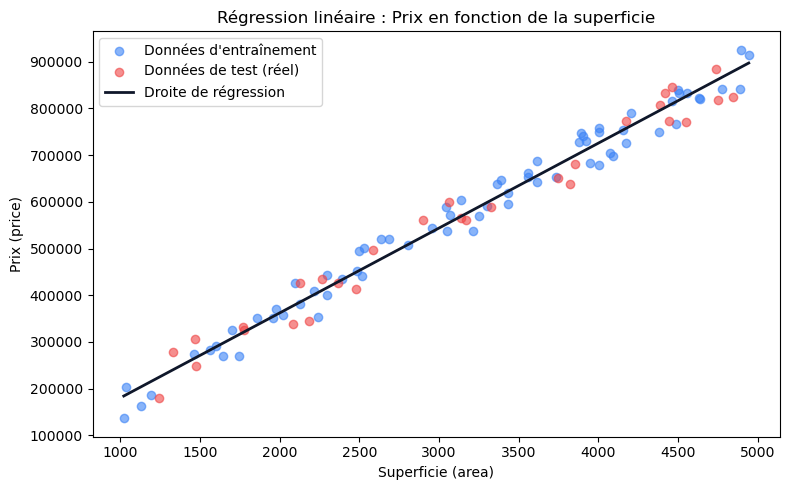

In [17]:
# =========================================================
# Visualisation : nuage de points + droite de régression
# =========================================================
plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color="#3b82f6", alpha=0.6, label="Données d'entraînement")
plt.scatter(X_test, y_test, color="#ef4444", alpha=0.6, label="Données de test (réel)")

x_line = pd.DataFrame({"area": np.linspace(df["area"].min(), df["area"].max(), 100)})
y_line = model.predict(x_line)
plt.plot(x_line, y_line, color="#0f172a", linewidth=2, label="Droite de régression")

plt.xlabel("Superficie (area)")
plt.ylabel("Prix (price)")
plt.title("Régression linéaire : Prix en fonction de la superficie")
plt.legend()
plt.tight_layout()
plt.savefig("regression_plot.png", dpi=150)
print("\nGraphique enregistré : regression_plot.png")